#### Test order generation

In [17]:
import random

def generate_random_partition(total_sum, num_parts):
    dividers = sorted(random.randint(0, total_sum) for _ in range(num_parts - 1))
    points = [0] + dividers + [total_sum]
    return [points[i+1] - points[i] for i in range(num_parts)]

def generate_test_orders_of_boxamt(boxamt):
    for row_id in range(boxamt*100, boxamt*100+100):
        values = generate_random_partition(boxamt, 10)
        row_data = [row_id] + values
        print(",".join(map(str, row_data)))

for boxamt in range(0):
    generate_test_orders_of_boxamt(boxamt)

#### BnB guarantee test csv data processing

- Completeness:                 !missing data!
    !! File contains 99/100 rows !!
- Completeness:                 !missing data!
    !! File contains 87/100 rows !!
- Completeness:                 !missing data!
    !! File contains 98/100 rows !!
- Completeness:                 !missing data!
    !! File contains 99/100 rows !!


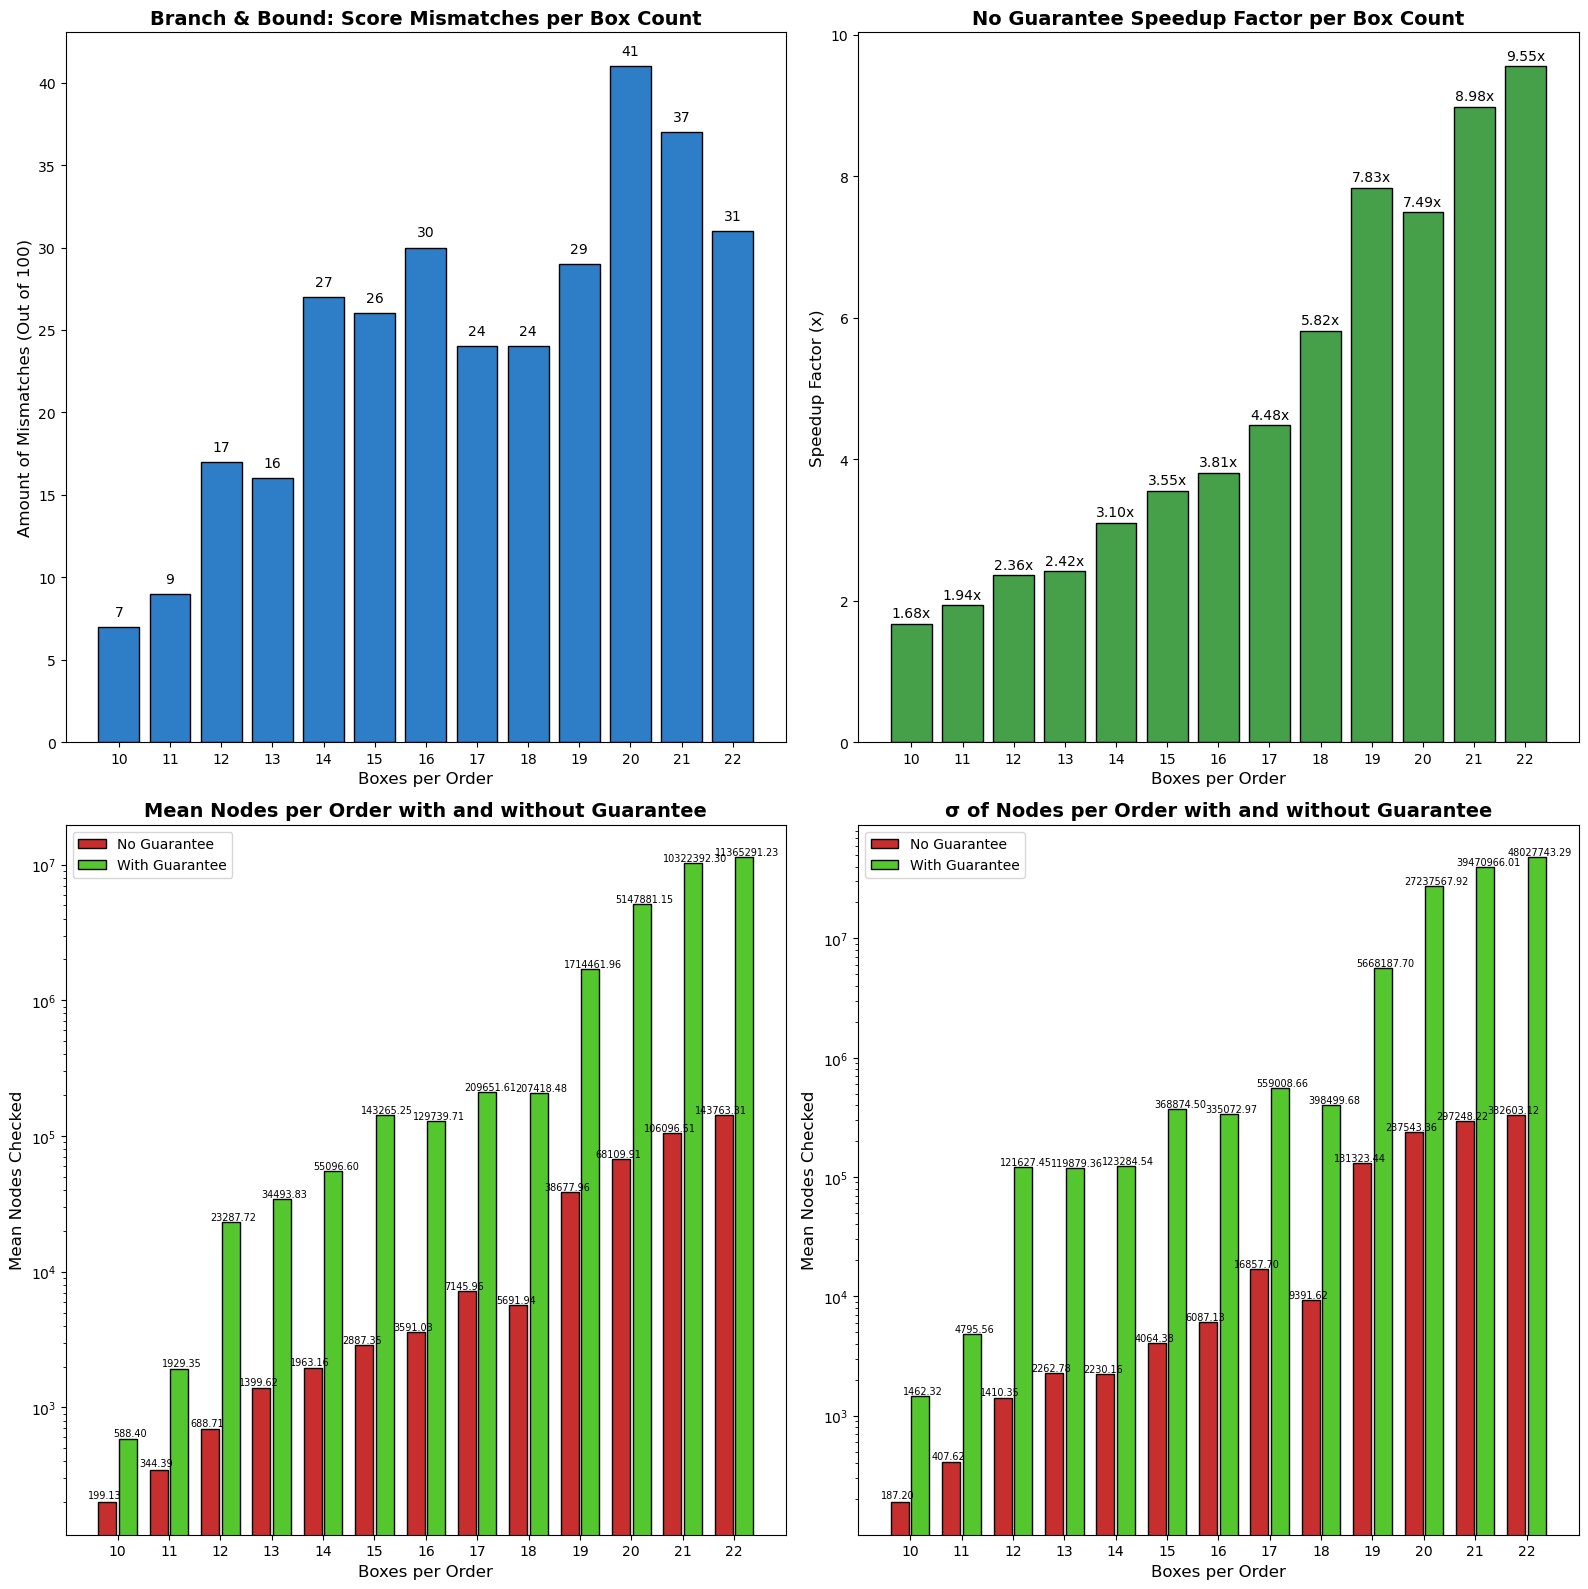

In [18]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRINT_MODE = False
SAVE_MODE = True

directory = './results/old_results/bnb_old_symbreak/bnb_comparisons'
csv_files = glob.glob(os.path.join(directory, '*9.csv'))
results_dict = {}

for filepath in csv_files:
    filename = os.path.basename(filepath)
    box_count = filename[25:27]
    df = pd.read_csv(filepath)

    if PRINT_MODE:
        print(f"\n--- Analysis of {box_count}-box orders ---")
    
    # Initialize the dictionary for this box group
    results_dict[box_count] = {
        'completeness_status':          'good',
        'mismatch_count':               0,
        'avg_score_diff':               0.0,
        'percent_improvement':          None,
        'speed_multiplier':             None,
        'mean_nodes_no_guarantee':      0,
        'sigma_nodes_no_guarantee':     0,
        'mean_nodes_with_guarantee':    0,
        'sigma_nodes_with_guarantee':   0,
    }
    
    # Missing data: check all non- *_factor columns for missing values
    cols_to_check = [c for c in df.columns if not c.endswith('_factor')]
    missing_data_cols = df[cols_to_check].isnull().any(axis=1)

    if len(df) == 100 and not missing_data_cols.any():
        if PRINT_MODE:
            print("- Completeness:                 good")
    else:
        results_dict[box_count]['completeness_status'] = False
        print(f"- Completeness:                 !missing data!")
        if len(df) != 100:
            print(f"    !! File contains {len(df)}/100 rows !!")
        if missing_data_cols.any():
            missing_ids = df[missing_data_cols]['order_id'].tolist()
            print(f"    !! Missing data in order IDs:")
            print(f"      {missing_ids}")

    # Count guarantee on/off score mismatches in orders
    mismatches = df[df['score_no_guarantee'] != df['score_with_guarantee']]
    mismatch_count = len(mismatches)
    results_dict[box_count]['mismatch_count'] = mismatch_count
    
    if mismatch_count > 0:
        avg_score_diff = abs(mismatches['score_no_guarantee'] - mismatches['score_with_guarantee']).mean()
        results_dict[box_count]['avg_score_diff'] = avg_score_diff
        if PRINT_MODE:
            print(f"- Score mismatches:             {mismatch_count}")
            print(f"- Average mismatch size:        {avg_score_diff:.2f}")
    else:
        if PRINT_MODE:
            print("- Score mismatches:             none")

    # Node evaluation number comparison
    df['nodes_diff_factor'] = pd.to_numeric(df['nodes_diff_factor'])
    avg_diff_factor = df['nodes_diff_factor'].mean()
    
    if pd.notna(avg_diff_factor) and avg_diff_factor > 0:
        percent_improvement = (1 - avg_diff_factor) * 100
        times_fewer = 1 / avg_diff_factor
        
        results_dict[box_count]['percent_improvement'] = percent_improvement
        results_dict[box_count]['speed_multiplier'] = times_fewer
        
        if PRINT_MODE:
            print(f"- Node improvement:             {percent_improvement:.2f}%")
            print(f"- No guarantee speedup:         {times_fewer:.2f}x")
    else:
        print("- Node improvement:             !error!")

    # Mean node amounts and standard deviation recording
    mean_nodes_no_guarantee    = df['nodes_no_guarantee'].mean()
    sigma_nodes_no_guarantee   = df['nodes_no_guarantee'].std()
    mean_nodes_with_guarantee  = df['nodes_with_guarantee'].mean()
    sigma_nodes_with_guarantee = df['nodes_with_guarantee'].std()

    results_dict[box_count]['mean_nodes_no_guarantee']    = mean_nodes_no_guarantee
    results_dict[box_count]['sigma_nodes_no_guarantee']   = sigma_nodes_no_guarantee
    results_dict[box_count]['mean_nodes_with_guarantee']  = mean_nodes_with_guarantee
    results_dict[box_count]['sigma_nodes_with_guarantee'] = sigma_nodes_with_guarantee

# Sort the dictionary by box_count
sorted_items = sorted(results_dict.items(), key=lambda x: int(x[0]) if x[0].isdigit() else x[0])

# Extract data for plotting
box_counts_list         = [item[0]                               for item in sorted_items]
mismatch_counts_list    = [item[1]['mismatch_count']             for item in sorted_items]
speedup_list            = [item[1]['speed_multiplier']           for item in sorted_items]
mean_nodes_no_g_list    = [item[1]['mean_nodes_no_guarantee']    for item in sorted_items]
sigma_nodes_no_g_list   = [item[1]['sigma_nodes_no_guarantee']   for item in sorted_items]
mean_nodes_with_g_list  = [item[1]['mean_nodes_with_guarantee']  for item in sorted_items]
sigma_nodes_with_g_list = [item[1]['sigma_nodes_with_guarantee'] for item in sorted_items]

# Create the plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 16))
thin_bar_width = 0.35

# Make x-axis as an array for multi-bar graphs
x_axis = np.arange(len(box_counts_list))
# x_axis = np.array(box_counts_list)

# Mismatch graph
ax1.bar(x_axis, mismatch_counts_list, color='#2e7dc7', edgecolor='black')
ax1.set_title('Branch & Bound: Score Mismatches per Box Count', fontsize=14, fontweight='bold')
ax1.set_xlabel('Boxes per Order', fontsize=12)
ax1.set_ylabel('Amount of Mismatches (Out of 100)', fontsize=12)
ax1.set_xticks(x_axis)
ax1.set_xticklabels(box_counts_list)

# Display the exact number on top of each bar
for index, value in enumerate(mismatch_counts_list):
    ax1.text(index, value + 0.5, str(value), ha='center', va='bottom', fontsize=10)

# Speedup graph
ax2.bar(x_axis, speedup_list, color='#45a049', edgecolor='black')
ax2.set_title('No Guarantee Speedup Factor per Box Count', fontsize=14, fontweight='bold')
ax2.set_xlabel('Boxes per Order', fontsize=12)
ax2.set_ylabel('Speedup Factor (x)', fontsize=12)
ax2.set_xticks(x_axis)
ax2.set_xticklabels(box_counts_list)

# Display exact numbers on top of each bar
for index, value in enumerate(speedup_list):
    if value > 0:
        ax2.text(index, value + 0.05, f"{value:.2f}x", ha='center', va='bottom', fontsize=10)

# Mean node graph (logarithmic)
ax3.bar(x_axis - 0.2, mean_nodes_no_g_list, thin_bar_width, label='No Guarantee', color="#c72e2e", edgecolor='black', log=True)
ax3.bar(x_axis + 0.2, mean_nodes_with_g_list, thin_bar_width, label='With Guarantee', color="#54c72e", edgecolor='black', log=True)
ax3.set_title('Mean Nodes per Order with and without Guarantee', fontsize=14, fontweight='bold')
ax3.set_xlabel('Boxes per Order', fontsize=12)
ax3.set_ylabel('Mean Nodes Checked', fontsize=12)
ax3.set_xticks(x_axis)
ax3.set_xticklabels(box_counts_list)
ax3.legend()

# Display exact numbers on top of each bar
for index, value in enumerate(mean_nodes_no_g_list):
    ax3.text(index - 0.25, value + 10, f"{value:.2f}", ha='center', va='bottom', fontsize=7)
for index, value in enumerate(mean_nodes_with_g_list):
    ax3.text(index + 0.25, value + 10, f"{value:.2f}", ha='center', va='bottom', fontsize=7)

# Node sigma graph (logarithmic)
ax4.bar(x_axis - 0.2, sigma_nodes_no_g_list, thin_bar_width, label='No Guarantee', color="#c72e2e", edgecolor='black', log=True)
ax4.bar(x_axis + 0.2, sigma_nodes_with_g_list, thin_bar_width, label='With Guarantee', color="#54c72e", edgecolor='black', log=True)
ax4.set_title('σ of Nodes per Order with and without Guarantee', fontsize=14, fontweight='bold')
ax4.set_xlabel('Boxes per Order', fontsize=12)
ax4.set_ylabel('Mean Nodes Checked', fontsize=12)
ax4.set_xticks(x_axis)
ax4.set_xticklabels(box_counts_list)
ax4.legend()

# Display exact numbers on top of each bar
for index, value in enumerate(sigma_nodes_no_g_list):
    ax4.text(index - 0.25, value + 10, f"{value:.2f}", ha='center', va='bottom', fontsize=7)
for index, value in enumerate(sigma_nodes_with_g_list):
    ax4.text(index + 0.25, value + 10, f"{value:.2f}", ha='center', va='bottom', fontsize=7)

plt.tight_layout()

# Save the figure if SAVE_MODE is True
if SAVE_MODE:
    save_path = './results/old_results/bnb_old_symbreak/bnb_performance_summary.png'
    plt.savefig(save_path, dpi=300)
    if PRINT_MODE:
        print(f"\n Figure successfully saved to: {save_path}")

plt.show()

#### CSV concatenation

In [19]:
import pandas as pd
from pathlib import Path
from collections import defaultdict

folder_path = Path('./results/bnb_comparisons')
csv_files = list(folder_path.glob('*.csv'))

grouped_files = defaultdict(list)

# Group files by box amount
for file in csv_files:
    try:
        box_amt = file.name.split('O')[1][:2]
        grouped_files[box_amt].append(file)
    except:
        print(f"Skipping {file.name}: naming scheme mismatch")
        continue

# Concatenate and sort each group
for box_amt, files in grouped_files.items():
    file_amt = len(files)
    combined_df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
    combined_df.sort_values(by=['order_id', 'topx_limit'], inplace=True)
    combined_df.reset_index(drop=True, inplace=True)
    order_range = f"{box_amt}00-{box_amt}99"
    
    # Check data completeness
    is_complete = (file_amt == 100) and (len(combined_df) == 1600)
    if is_complete:
        output_file = Path(f'./results/topx_comparisons_collated/topx_comparison_{order_range}.csv')
        combined_df.to_csv(output_file, index=False)
        print(f"[{order_range}] Successfully combined 100 files")
    elif file_amt >= 50:
        output_file = Path(f'./results/topx_comparisons_collated/topx_comparison_{order_range}_incomplete.csv')
        combined_df.to_csv(output_file, index=False)
        print(f"[{order_range}] Saved as incomplete: Found {file_amt}/100 files and {len(combined_df) + 1}/1600 lines")
    else:
        print(f"[{order_range}] Not saved: Found {file_amt}/100 files and {len(combined_df) + 1}/1600 lines")

[1600-1699] Saved as incomplete: Found 101/100 files and 1607/1600 lines
[1900-1999] Successfully combined 100 files
[1500-1599] Successfully combined 100 files
[1800-1899] Successfully combined 100 files
[2100-2199] Successfully combined 100 files
[1700-1799] Successfully combined 100 files
[2300-2399] Saved as incomplete: Found 93/100 files and 1489/1600 lines
[2000-2099] Successfully combined 100 files
[1300-1399] Successfully combined 100 files
[2800-2899] Saved as incomplete: Found 69/100 files and 1105/1600 lines
[2600-2699] Saved as incomplete: Found 87/100 files and 1393/1600 lines
[1400-1499] Successfully combined 100 files
[1100-1199] Successfully combined 100 files
[2200-2299] Saved as incomplete: Found 95/100 files and 1521/1600 lines
[1200-1299] Successfully combined 100 files
[2400-2499] Saved as incomplete: Found 91/100 files and 1457/1600 lines
[2900-2999] Not saved: Found 11/100 files and 167/1600 lines
[2500-2599] Saved as incomplete: Found 87/100 files and 1393/1600 

#### CSV missing data finder

In [20]:
import pandas as pd
from pathlib import Path

def find_missing_orders(start_id=1000, end_id=2999):
    collated_folder = Path('./results/topx_comparisons_collated')
    collated_files = list(collated_folder.glob('topx_comparison_*.csv'))
    found_order_ids = set()
    
    for file in collated_files:
        df = pd.read_csv(file, usecols=['order_id'])
        found_order_ids.update(df['order_id'].dropna().unique())

    expected_order_ids = set(range(start_id, end_id + 1))
    missing_orders = sorted(list(expected_order_ids - found_order_ids))
    
    if not missing_orders:
        print("All expected orders are present. Nothing is missing!")
    else:
        print(f"Missing {len(missing_orders)} orders:")
        print(missing_orders)

find_missing_orders(start_id=1000, end_id=3000)

Missing 204 orders:
[2207, 2224, 2249, 2288, 2296, 2305, 2311, 2327, 2347, 2356, 2386, 2399, 2403, 2405, 2418, 2421, 2448, 2461, 2462, 2483, 2491, 2500, 2505, 2529, 2541, 2545, 2554, 2558, 2561, 2570, 2580, 2582, 2584, 2593, 2611, 2622, 2636, 2640, 2658, 2659, 2661, 2662, 2663, 2669, 2685, 2687, 2697, 2708, 2709, 2719, 2726, 2728, 2729, 2736, 2737, 2741, 2743, 2744, 2746, 2754, 2755, 2762, 2768, 2771, 2773, 2782, 2788, 2789, 2790, 2795, 2798, 2799, 2804, 2806, 2809, 2811, 2812, 2816, 2820, 2821, 2826, 2827, 2832, 2834, 2839, 2842, 2843, 2845, 2858, 2862, 2863, 2866, 2869, 2871, 2874, 2875, 2880, 2888, 2889, 2893, 2896, 2898, 2899, 2900, 2901, 2902, 2903, 2904, 2905, 2906, 2907, 2908, 2909, 2910, 2911, 2912, 2913, 2914, 2915, 2916, 2917, 2918, 2919, 2920, 2921, 2922, 2923, 2924, 2925, 2926, 2927, 2928, 2929, 2930, 2931, 2932, 2933, 2934, 2935, 2936, 2937, 2938, 2939, 2940, 2941, 2942, 2943, 2944, 2945, 2946, 2947, 2948, 2949, 2950, 2951, 2952, 2953, 2954, 2955, 2956, 2957, 2958, 2959, 2

#### BnB Top-X test csv data processing

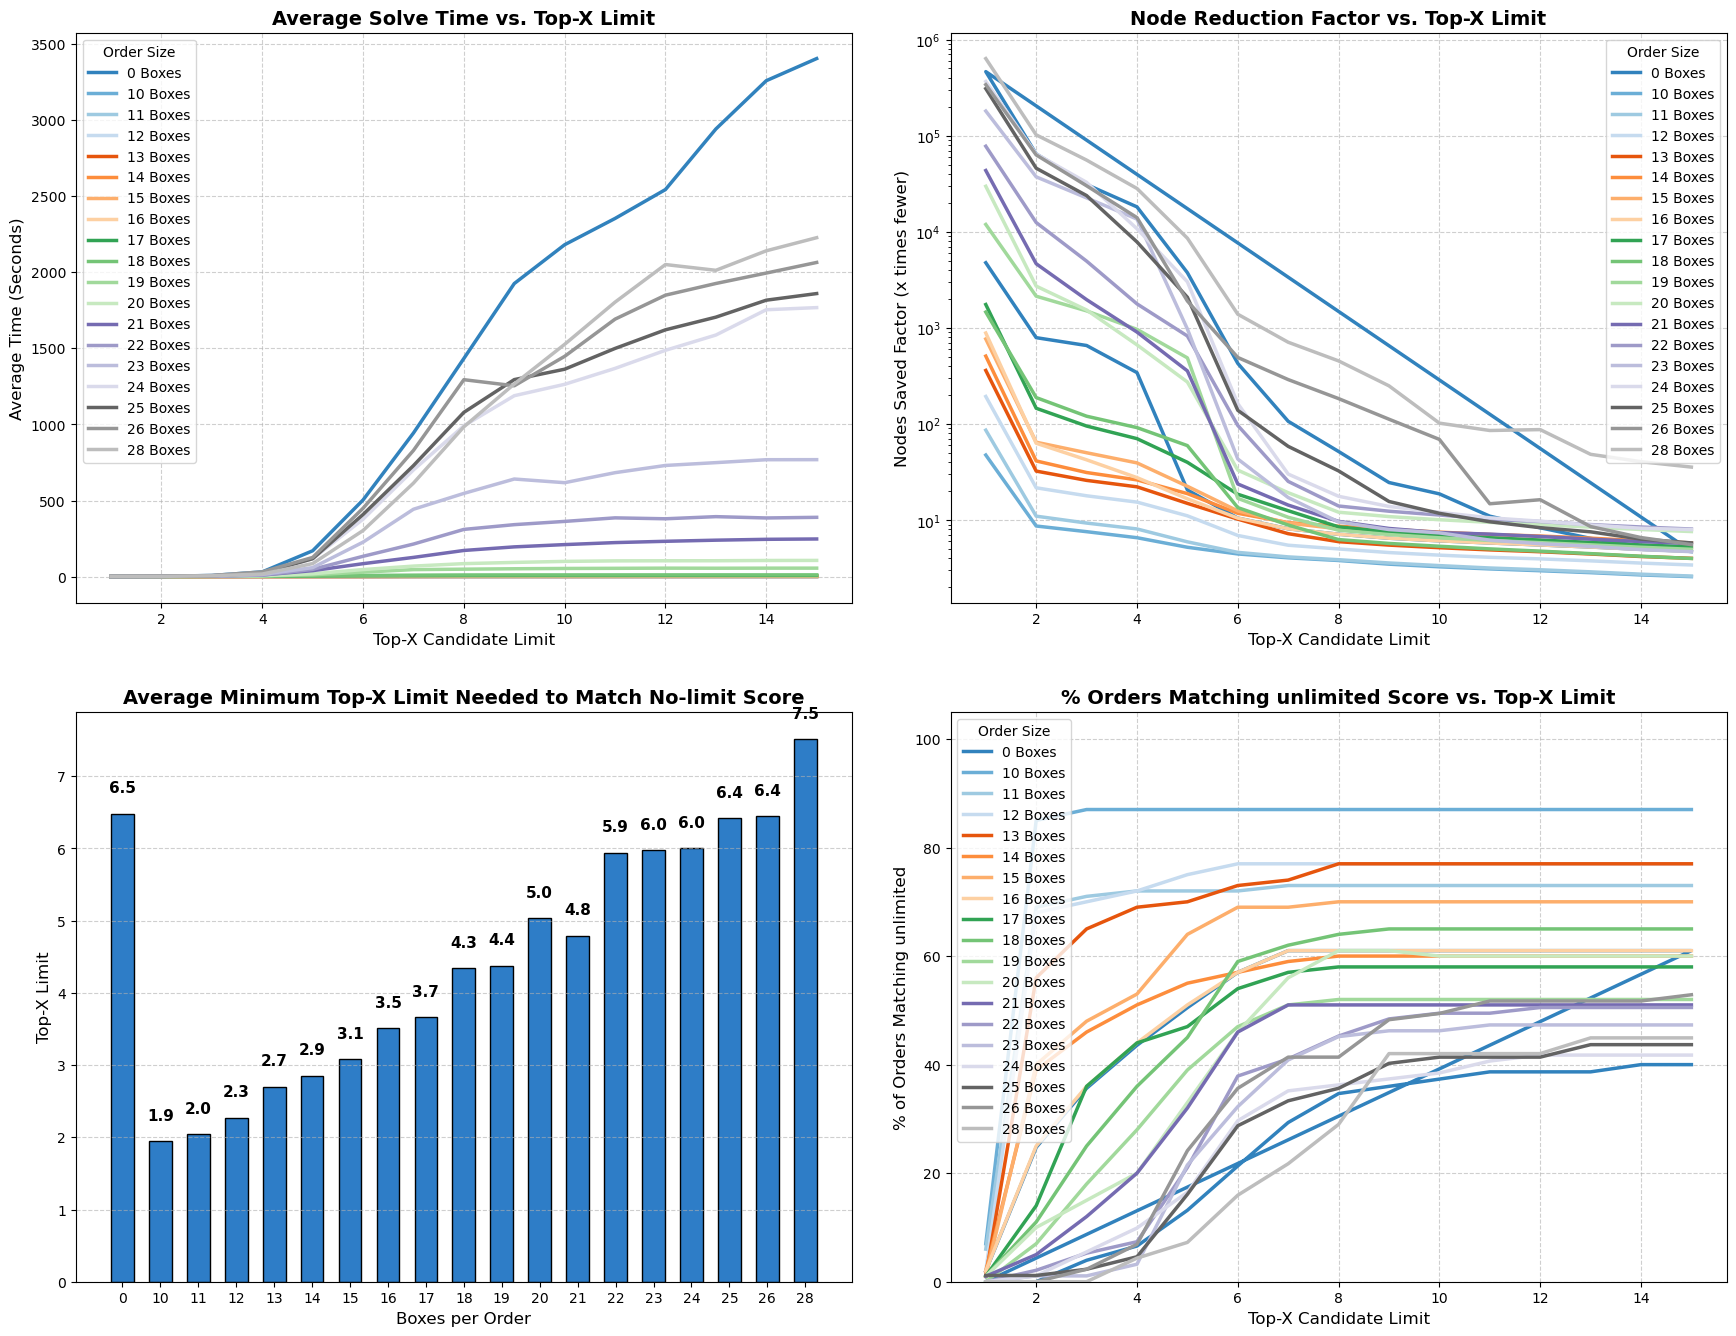

In [21]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Settings
SAVE_MODE   = True
csv_dir     = './results/topx_comparisons_collated/'

# Initializations
csv_files   = glob.glob(os.path.join(csv_dir, '*topx*.csv'))
results_dict = {}
aggregated_limit_data = []

for filepath in csv_files:
    filename = os.path.basename(filepath)
    df = pd.read_csv(filepath)
    
    # Extract box count from the first order_id
    if len(df) == 0:
        continue
    box_count = str(df['order_id'].iloc[0] // 100)

    # PRECALCULATIONS
    # Timing 
    df['total_seconds'] = df['time_taken (min)'] * 60 + df['(seconds)']                                 # Convert min,sec time to seconds

    # DF manipulation
    baseline_df = df[df['topx_limit'] == -1][['order_id', 'score', 'nodes']].copy()                     # Extract no-limit (-1 limit) data
    baseline_df.rename(columns={'score': 'base_score', 'nodes': 'base_nodes'}, inplace=True)            # Rename baseline columns to prevent overwriting with merge
    df = df.merge(baseline_df, on='order_id', how='left')                                               # Add baseline data back to df for easy comparison
    limits_df = df[df['topx_limit'] != -1].copy()                                                       # Get df without baseline rows for calculations on limited runs
    
    # Node improvement
    limits_df['node_improvement_factor'] = limits_df['base_nodes'] / limits_df['nodes']                 # Calculate node improvement and put it in new column
    
    # Unlimited score matches
    limits_df['matches_unlimited'] = limits_df['score'] == limits_df['base_score']                      # Check if score matches unlimited and put it in new column
    unlimited_matches = limits_df[limits_df['matches_unlimited']]                                       # Filter only rows that matched unlimited
    min_limit_per_order = unlimited_matches.groupby('order_id')['topx_limit'].min()                     # Get the minimal limit per order from filtered df
    avg_min_limit = min_limit_per_order.mean()                                                          # Get the average across orders
    perfect_match_count = len(min_limit_per_order)                                                      # Get the amount of matches of matches with unlimited
    
    groups_by_limit = limits_df.groupby('topx_limit').agg(                                              # Aggregate groups by limit to extract avg time, avg improvement, and score match rate
        avg_time=('total_seconds', 'mean'),
        avg_node_improvement=('node_improvement_factor', 'mean'),
        unlimited_match_rate=('matches_unlimited', 'mean')
    ).reset_index()
    
    # Store aggregated line data for the charts
    groups_by_limit['box_count'] = box_count
    aggregated_limit_data.append(groups_by_limit)
    
    # Store single-value metrics for the bar charts
    results_dict[box_count] = {
        'avg_min_limit': avg_min_limit,
        'perfect_match_count': perfect_match_count
    }

# Combine all limit data into one df
all_limits_df = pd.concat(aggregated_limit_data, ignore_index=True)
box_counts_sorted = sorted(results_dict.keys(), key=int)

# VISUALIZATIONS
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))
cmap = plt.get_cmap('tab20c')
colors = [cmap(i % 20) for i in range(len(box_counts_sorted))]

# Figure 1: time vs limit value
for i, bc in enumerate(box_counts_sorted):
    data = all_limits_df[all_limits_df['box_count'] == bc]
    ax1.plot(data['topx_limit'], data['avg_time'], linewidth=2.5, label=f'{bc} Boxes', color=colors[i])

ax1.set_title('Average Solve Time vs. Top-X Limit', fontsize=14, fontweight='bold')
ax1.set_xlabel('Top-X Candidate Limit', fontsize=12)
ax1.set_ylabel('Average Time (Seconds)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(title='Order Size')

# Figure 2: node reduction vs limit value
for i, bc in enumerate(box_counts_sorted):
    data = all_limits_df[all_limits_df['box_count'] == bc]
    ax2.plot(data['topx_limit'], data['avg_node_improvement'], linewidth=2.5, label=f'{bc} Boxes', color=colors[i])

ax2.set_title('Node Reduction Factor vs. Top-X Limit', fontsize=14, fontweight='bold')
ax2.set_xlabel('Top-X Candidate Limit', fontsize=12)
ax2.set_ylabel('Nodes Saved Factor (x times fewer)', fontsize=12)
ax2.set_yscale('log') # Log scale is great here since 1 limit might be 1000x faster, and 50 limit is 2x faster
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(title='Order Size')

# Figure 3: average min limit value to reach matched score
x_axis = np.arange(len(box_counts_sorted))
avg_min_limits = [results_dict[bc]['avg_min_limit'] for bc in box_counts_sorted]

bars = ax3.bar(x_axis, avg_min_limits, color='#2e7dc7', edgecolor='black', width=0.6)
ax3.set_title('Average Minimum Top-X Limit Needed to Match No-limit Score', fontsize=14, fontweight='bold')
ax3.set_xlabel('Boxes per Order', fontsize=12)
ax3.set_ylabel('Top-X Limit', fontsize=12)
ax3.set_xticks(x_axis)
ax3.set_xticklabels(box_counts_sorted)
ax3.grid(axis='y', linestyle='--', alpha=0.6)

# Put values on bars
for index, value in enumerate(avg_min_limits):
    ax3.text(index, value + 0.25, f"{value:.1f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

# Figure 4: order percentage matching no-limit score vs limit value
for i, bc in enumerate(box_counts_sorted):
    data = all_limits_df[all_limits_df['box_count'] == bc]
    ax4.plot(data['topx_limit'], data['unlimited_match_rate'] * 100, linewidth=2.5, label=f'{bc} Boxes', color=colors[i])

ax4.set_title('% Orders Matching unlimited Score vs. Top-X Limit', fontsize=14, fontweight='bold')
ax4.set_xlabel('Top-X Candidate Limit', fontsize=12)
ax4.set_ylabel('% of Orders Matching unlimited', fontsize=12)
ax4.set_ylim(0, 105)
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.legend(title='Order Size')

plt.tight_layout(pad=3.0)

# Save the figure if SAVE_MODE is True
if SAVE_MODE:
    os.makedirs('./results', exist_ok=True)
    save_path = './results/topx_performance_summary.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

#### BnB Algo Comparison Data Processing

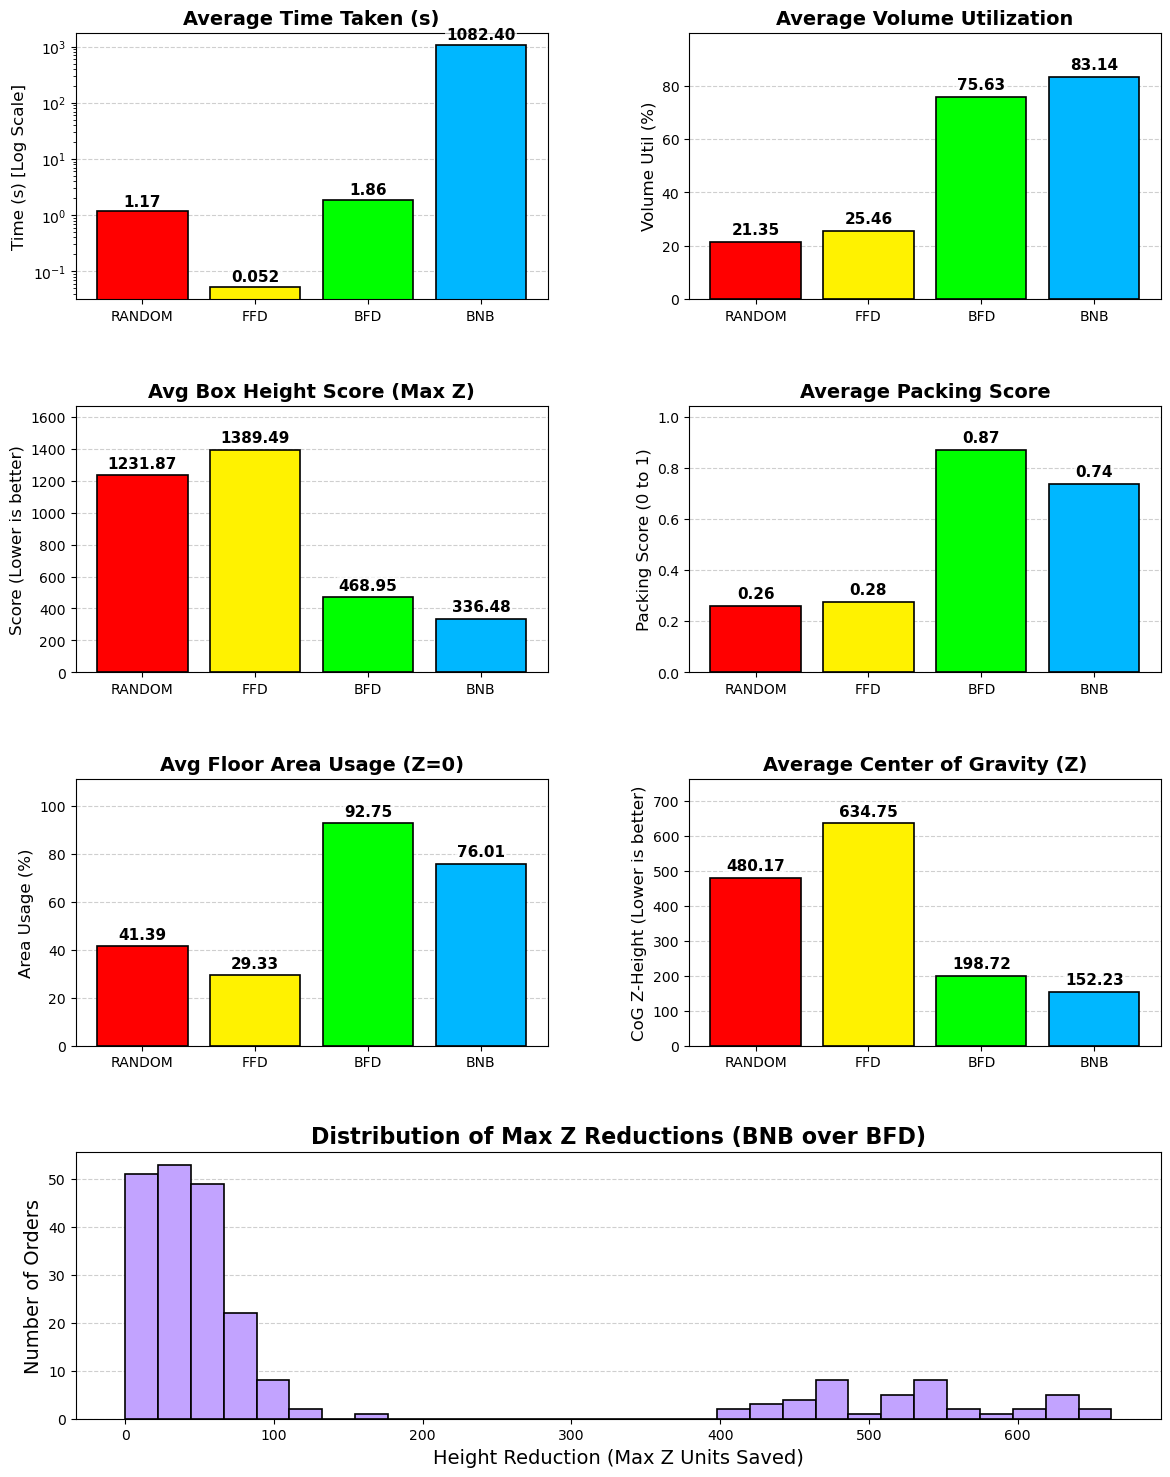

In [25]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Configuration
TESTING_TEST_ORDERS = True
SAVE_MODE = False

if TESTING_TEST_ORDERS:
    data_path = "./results/algo_comparisons/test_orders/algorithm_comparison_T*_to_T*.csv"
else:
    data_path = "./results/algo_comparisons/given_orders/algorithm_comparison_O*_to_O*.csv"

# Data loading and preprocessing by glob
all_files = glob.glob(data_path)

if not all_files:
    print(f"No CSV files found in directory: {data_path}")
else:
    df_list = [pd.read_csv(f) for f in all_files]
    combined_df = pd.concat(df_list, ignore_index=True)

    # Data aggregation
    agg_df = combined_df.groupby('algorithm').agg({
        'time_taken (s)': 'mean',
        'volume_util (%)': 'mean',
        'score (max_z)': 'mean',
        'packing_score': 'mean',
        'area_usage_z0 (%)': 'mean',
        'cog_z': 'mean'
    }).reset_index()

    algo_order = ['RANDOM', 'FFD', 'BFD', 'BNB']
    agg_df['algorithm'] = pd.Categorical(agg_df['algorithm'], categories=algo_order, ordered=True)
    agg_df = agg_df.sort_values('algorithm')

    # Histogram processing 
    pivot_df = combined_df.pivot_table(index='order_id', columns='algorithm', values='score (max_z)').reset_index()     # Pivot DF so each row is an order_id and columns are algorithms
    pivot_df['bnb_improvement'] = pivot_df['BFD'] - pivot_df['BNB']                                                     # Calculate how much BNB reduced the height compared to BFD

    # Graph creation
    fig = plt.figure(figsize=(14, 18))
    gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.4, wspace=0.3)                                                    # Premake the graph grid

    # 6 normal subplots and the double wide histogram
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])
    ax5 = fig.add_subplot(gs[2, 0])
    ax6 = fig.add_subplot(gs[2, 1])
    ax7 = fig.add_subplot(gs[3, :])

    colors = ["#ff0000", "#fff200", "#00ff00", "#00b7ff"]

    # Helper function for bars
    def plot_bar(ax, x, y, title, ylabel, log_y=False):
        bars = ax.bar(x, y, color=colors, edgecolor='black', linewidth=1.2)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=12)
        ax.grid(True, axis='y', linestyle='--', alpha=0.6)
        ax.set_axisbelow(True)
        
        if log_y:
            ax.set_yscale('log')
            
        for bar in bars:
            height = bar.get_height()
            label_text = f"{height:.3f}" if height < 0.1 else f"{height:.2f}"
            y_pos = height * 1.1 if log_y else height + (max(y)*0.02)
            
            ax.text(bar.get_x() + bar.get_width()/2., y_pos, label_text, 
                    ha='center', va='bottom', fontsize=11, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # Bar charts
    plot_bar(ax1, agg_df['algorithm'], agg_df['time_taken (s)'], 
             'Average Time Taken (s)', 'Time (s) [Log Scale]', log_y=True)
    
    plot_bar(ax2, agg_df['algorithm'], agg_df['volume_util (%)'], 
             'Average Volume Utilization', 'Volume Util (%)')
    ax2.set_ylim(0, max(agg_df['volume_util (%)']) * 1.2)

    plot_bar(ax3, agg_df['algorithm'], agg_df['score (max_z)'], 
             'Avg Box Height Score (Max Z)', 'Score (Lower is better)')
    ax3.set_ylim(0, max(agg_df['score (max_z)']) * 1.2)

    plot_bar(ax4, agg_df['algorithm'], agg_df['packing_score'], 
             'Average Packing Score', 'Packing Score (0 to 1)')
    ax4.set_ylim(0, max(agg_df['packing_score']) * 1.2)

    plot_bar(ax5, agg_df['algorithm'], agg_df['area_usage_z0 (%)'], 
             'Avg Floor Area Usage (Z=0)', 'Area Usage (%)')
    ax5.set_ylim(0, max(agg_df['area_usage_z0 (%)']) * 1.2)

    plot_bar(ax6, agg_df['algorithm'], agg_df['cog_z'], 
             'Average Center of Gravity (Z)', 'CoG Z-Height (Lower is better)')
    ax6.set_ylim(0, max(agg_df['cog_z']) * 1.2)

    # Histogram
    n, bins, patches = ax7.hist(pivot_df['bnb_improvement'].dropna(), bins=30, 
                                color='#c2a3ff', edgecolor='black', linewidth=1.2)
    ax7.set_title('Distribution of Max Z Reductions (BNB over BFD)', fontsize=16, fontweight='bold')
    ax7.set_xlabel('Height Reduction (Max Z Units Saved)', fontsize=14)
    ax7.set_ylabel('Number of Orders', fontsize=14)
    ax7.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax7.set_axisbelow(True)

    # Save figure if SAVE_MODE is True
    if SAVE_MODE:
        os.makedirs('./results', exist_ok=True)
        
        if TESTING_TEST_ORDERS:
            save_filename = 'algorithm_test_orders_comparison.png' 
        else:
            save_filename = 'algorithm_given_orders_comparison.png'
        save_path = f'./results/{save_filename}'
        
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved successfully to: {save_path}")
    
    plt.show()